<hr/>

# Foundations of Reinforcement Learning

<hr/>

<h1><font color="darkblue">Lab 2: Dynamic Programming </font></h1>





##  Content
1. Problem statement
0. Dynamic Programming algorithm


In [112]:
%pylab inline
import numpy as np
import builtins
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/opt/anaconda3/envs/RLHW/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['bar']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


## Problem Statement [P 29, Ch 1.3, Bertsekas]

#### A driver is looking for inexpensive parking on the way to his destination. The parking area contains $N$ spaces, and a garage at the end. The driver starts at space 0 and traverses the parking spaces sequentially, i.e., from space $k$ he goes next to space $k+1$, etc. Each parking space $k$ costs $c(k)$ and is free (unoccupied) with probability $p(k)$ independently of whether other parking spaces are free or not. If the driver reaches the last parking space and does not park there, he must park at the garage, which costs $C$. The driver can observe whether a parking space is free only when he reaches it, and then, if it is free, he makes a decision to park in that space or not to park and check the next space. The problem is to find the minimum expected cost parking policy.

In [113]:
# write any global function here if needed
N=200
C=100
pk=0.05
def IF_Free(k):
    if random.random() < pk:
        return 1
    else:
        return 0
def cost_to_pay(k):
    if k==N:
        return C
    else:
        return N-k

## Problem 1.  Dynamic Programming (DP) algorithm

1. (30 pts) Assume $N=200$, $C=100$; $p(k)\equiv0.05$ and $c(k)=N-k$ for all $k\in[0,N-1]$, please:
<br>   (a) Implement the Dynamic Programming algorithm to generate the expected cost-to-go upon arriving at each space $k$, if we always park at the first available space;
<br>   (b) Implement the Dynamic Programming algorithm to generate the optimal expected cost-to-go upon arriving at each space $k$;
<br>   (c) Plot and compare (a) and (b).
<br>   (d) Plot the optimal action to do at each space $k$.


2. (10 pts) You now have the freedom to change $C$, $p(k)$ and $c(k)$. Please come up with different parameters such that: 
<br>   (a) parking at the first available space is the optimal policy;
<br>   (b) not parking until reach the garage is the optimal policy.

      and plot optimal expected cost-to-go upon arriving at each space k repectively.


### 1.a

In [115]:
# always park at the first free space
def park_at_first_free():
    for k in range(0,N+1):
        if IF_Free(k)==1:
            break
    return k,cost_to_pay(k)

cost_list=[]
for i in range(100000):
    k,c=park_at_first_free()
    cost_list.append(c)
expected_cost=np.mean(cost_list)
print("Expected cost of parking at the first free space:", expected_cost)
    

Expected cost of parking at the first free space: 181.01518


### 1.b

In [117]:
# optimal strategy: park at the first free space after k0
def park_at_optimal(k0):
    for k in range(0,N+1):
        if IF_Free(k)==1:
            if k>=k0:
                break
    return k,cost_to_pay(k)

# Dynamic Programming approach
V = [0]*(N+1)
V[N] = C  # boundary condition

# Bellman equation: V[k] = p*min(c(k), V[k+1]) + (1-p)*V[k+1]
for k in range(N-1, -1, -1):
    V[k] = pk*builtins.min(cost_to_pay(k),V[k+1])+(1-pk)*V[k+1]

# Find k0: minimum k where c(k) <= V[k+1]
k0 = N  # default to garage
for k in range(N):
    if cost_to_pay(k) <= V[k+1]:
        k0 = k
        break
print("Optimal k0:", k0)

optimal_cost_list=[]
for i in range(100000):
    k,c=park_at_optimal(k0)
    optimal_cost_list.append(c)
optimal_expected_cost=np.mean(optimal_cost_list)
print("Expected cost of optimal policy is:", optimal_expected_cost)


Optimal k0: 165
Expected cost of optimal policy is: 35.75872


### 1.c

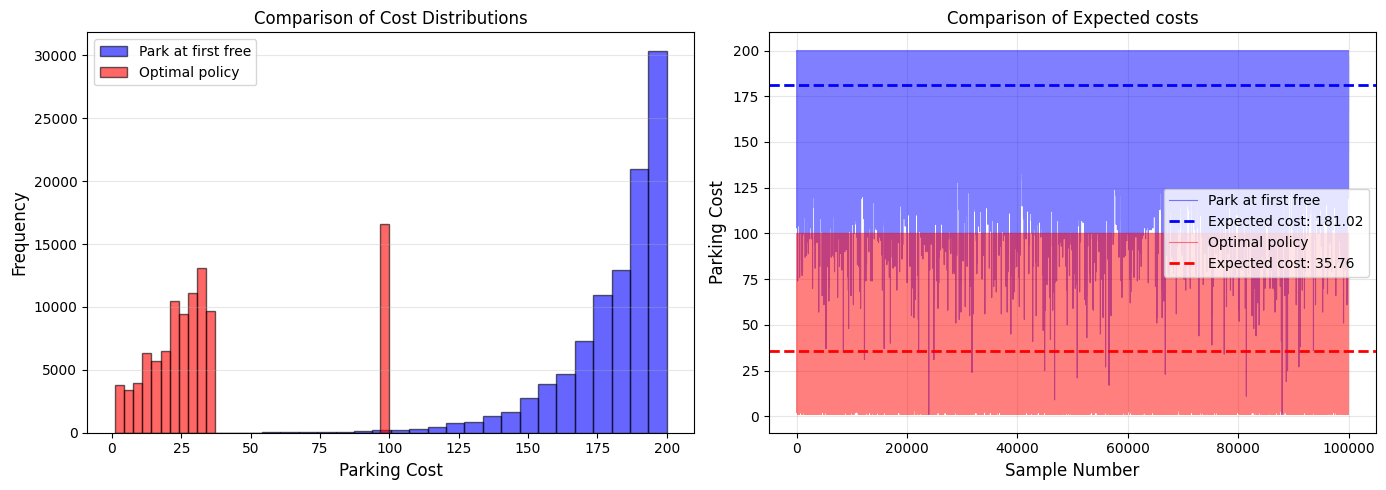

In [118]:
#plot two policies
plt.figure(figsize=(14, 5))

#Histogram comparison
plt.subplot(1, 2, 1)
plt.hist(cost_list, bins=30, alpha=0.6, label='Park at first free', color='blue', edgecolor='black')
plt.hist(optimal_cost_list, bins=30, alpha=0.6, label='Optimal policy', color='red', edgecolor='black')
plt.xlabel('Parking Cost', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Comparison of Cost Distributions', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

#Cost samples with expected value lines
plt.subplot(1, 2, 2)
plt.plot(cost_list, label='Park at first free', color='blue', alpha=0.5, linewidth=0.8)
plt.axhline(y=expected_cost, color='blue', linestyle='--', linewidth=2, label=f'Expected cost: {expected_cost:.2f}')
plt.plot(optimal_cost_list, label='Optimal policy', color='red', alpha=0.5, linewidth=0.8)
plt.axhline(y=optimal_expected_cost, color='red', linestyle='--', linewidth=2, label=f'Expected cost: {optimal_expected_cost:.2f}')
plt.xlabel('Sample Number', fontsize=12)
plt.ylabel('Parking Cost', fontsize=12)
plt.title('Comparison of Expected costs', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.d

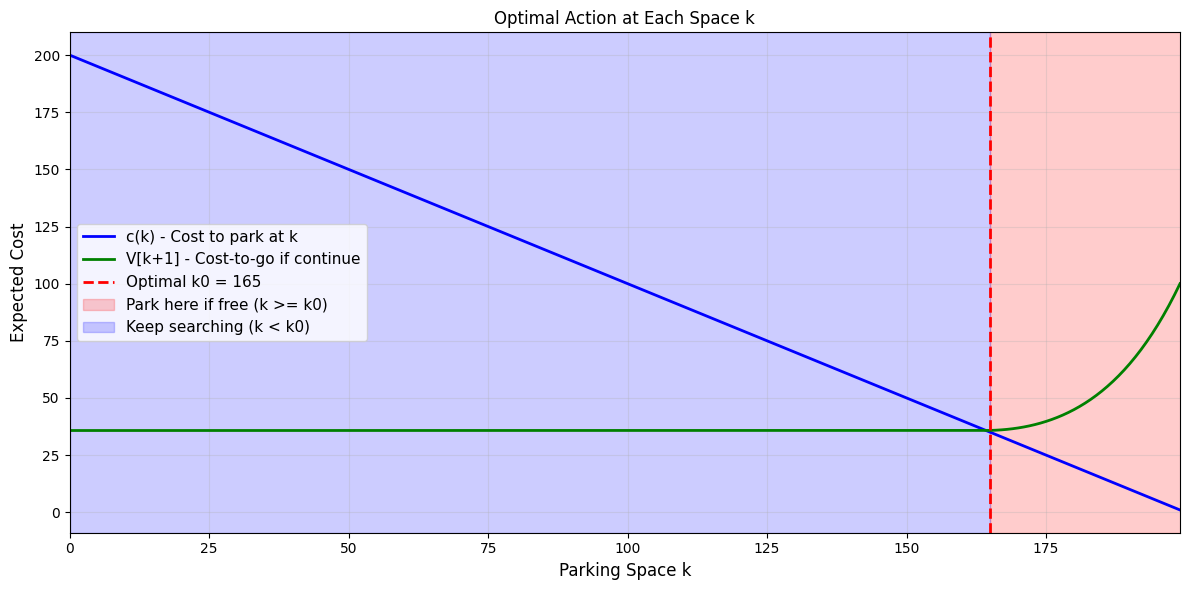


Optimal Policy:
For k < 165: Continue searching for better parking
For k >= 165: Park at first available space


In [119]:
# Plot optimal action at each space k
k_values=[]
cost_values=[]
v_next_values=[]
for k in range(N):
    k_values.append(k)
    cost_values.append(cost_to_pay(k))
    v_next_values.append(V[k+1])

plt.figure(figsize=(12, 6))

# Plot cost(k) and V[k+1]
plt.plot(k_values, cost_values, 'b-', linewidth=2, label='c(k) - Cost to park at k')
plt.plot(k_values, v_next_values, 'g-', linewidth=2, label='V[k+1] - Cost-to-go if continue')

# Fill regions to show optimal decisions
plt.axvline(x=k0, color='red', linestyle='--', linewidth=2, label=f'Optimal k0 = {k0}')
plt.axvspan(k0, N, alpha=0.2, color='red', label='Park here if free (k >= k0)')
plt.axvspan(0, k0, alpha=0.2, color='blue', label='Keep searching (k < k0)')

plt.xlabel('Parking Space k', fontsize=12)
plt.ylabel('Expected Cost', fontsize=12)
plt.title('Optimal Action at Each Space k', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, N-1)

plt.tight_layout()
plt.show()

print(f"\nOptimal Policy:")
print(f"For k < {k0}: Continue searching for better parking")
print(f"For k >= {k0}: Park at first available space")

### 2.a

Parameters: N=200, C=1000, p(k)=0.1, c(k)=5
Optimal k0: 0
Expected cost-to-go at k=0: 5.00


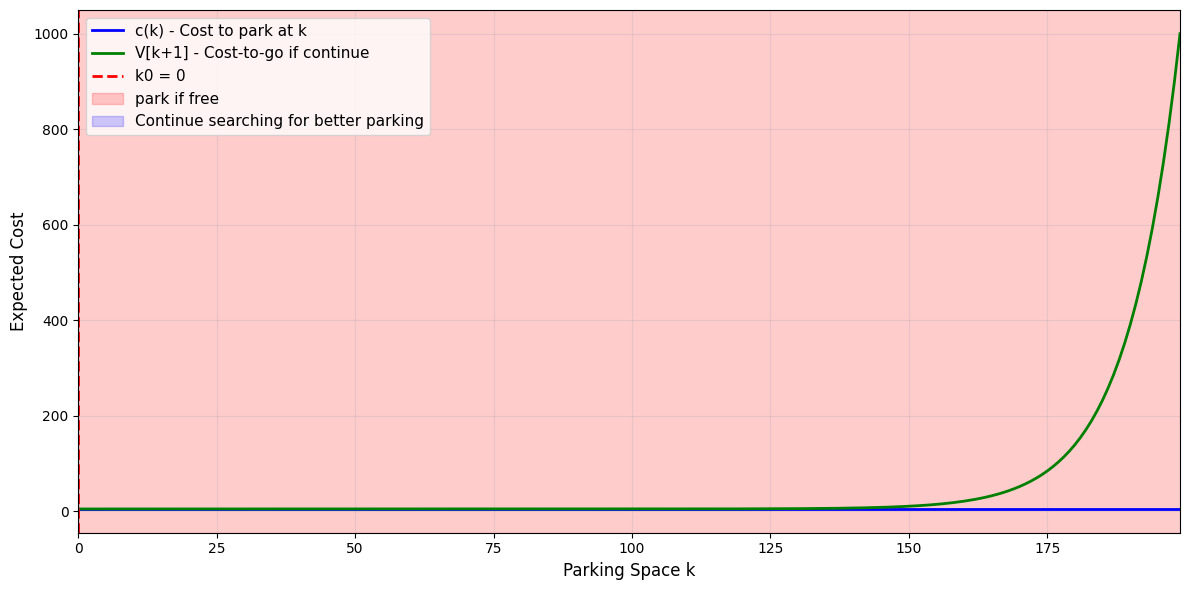

In [127]:
# Parking at the first available space is optimal (k0 = 0)
# Strategy: Make garage very expensive and parking cheap
N_2a = 200
C_2a = 1000  # Very high garage cost
pk_2a = 0.1  # Higher probability of finding free space
ck_2a = 5  # Very low parking cost
def cost_2a(k):
    if k == N_2a:
        return C_2a
    else:
        return ck_2a 

# DP
V_2a = [0] * (N_2a + 1)
V_2a[N_2a] = C_2a

for k in range(N_2a - 1, -1, -1):
    V_2a[k] = pk_2a * builtins.min(cost_2a(k), V_2a[k+1]) + (1 - pk_2a) * V_2a[k+1]

# Find k0
k0_2a = N_2a
for k in range(N_2a):
    if cost_2a(k) <= V_2a[k+1]:
        k0_2a = k
        break

print(f"Parameters: N={N_2a}, C={C_2a}, p(k)={pk_2a}, c(k)={ck_2a}")
print(f"Optimal k0: {k0_2a}")
print(f"Expected cost-to-go at k=0: {V_2a[0]:.2f}")

# Plot case 2a
k_values_2a = list(range(N_2a))
cost_values_2a = [cost_2a(k) for k in k_values_2a]
v_next_values_2a = [V_2a[k+1] for k in k_values_2a]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_values_2a, cost_values_2a, 'b-', linewidth=2, label='c(k) - Cost to park at k')
ax.plot(k_values_2a, v_next_values_2a, 'g-', linewidth=2, label='V[k+1] - Cost-to-go if continue')
ax.axvline(x=k0_2a, color='red', linestyle='--', linewidth=2, label=f'k0 = {k0_2a}')
ax.axvspan(k0_2a if k0_2a >= 0 else 0, N_2a, alpha=0.2, color='red', label='park if free')
ax.axvspan(0, k0_2a, alpha=0.2, color='blue', label='Continue searching for better parking')

ax.set_xlabel('Parking Space k', fontsize=12)
ax.set_ylabel('Expected Cost', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, N_2a-1)
plt.tight_layout()
plt.show()



### 2.b

Parameters: N=200, C=50, p(k)=0.001, c(k)=100+k
Optimal k0: 200
Expected cost-to-go at k=0: 50.00


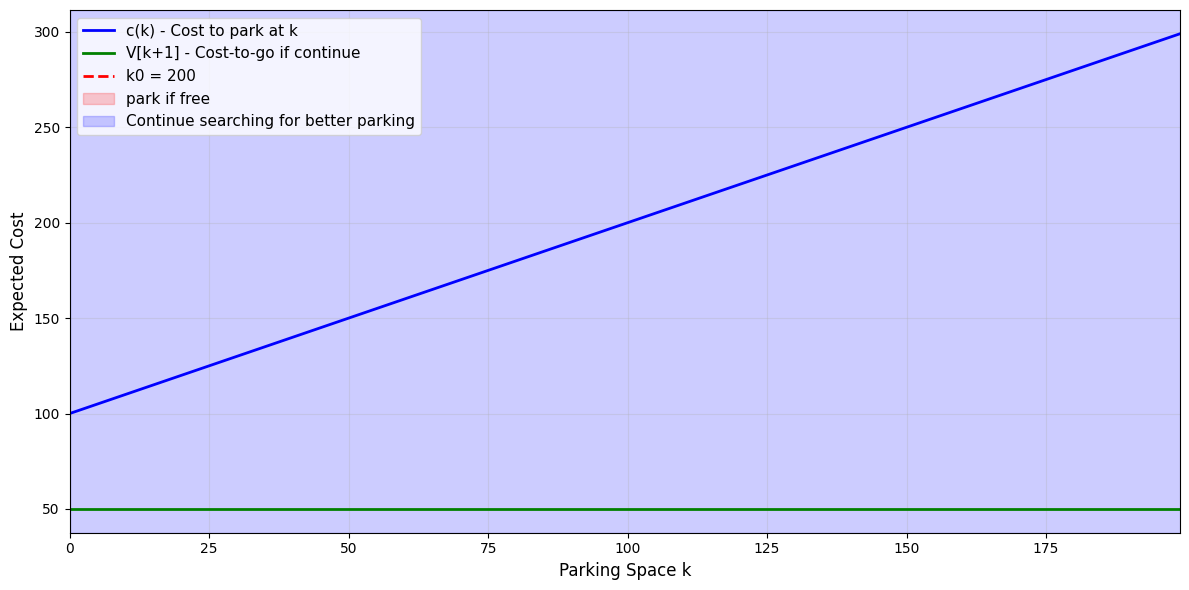

In [131]:
# Parking until reach garage (k0 = 200)
# Strategy: Make garage very expensive and parking cheap
N_2b = 200
C_2b = 50  # Very cheap garage cost
pk_2b = 0.001  # lower probability of finding free space
#ck_2b = 100+k  # Very high parking cost
def cost_2b(k):
    if k == N_2b:
        return C_2b
    else:
        return 100+k

# DP
V_2b = [0] * (N_2b + 1)
V_2b[N_2b] = C_2b

for k in range(N_2b - 1, -1, -1):
    V_2b[k] = pk_2b * builtins.min(cost_2b(k), V_2b[k+1]) + (1 - pk_2b) * V_2b[k+1]

# Find k0
k0_2b = N_2b
for k in range(N_2b):
    if cost_2b(k) <= V_2b[k+1]:
        k0_2b = k
        break

print(f"Parameters: N={N_2b}, C={C_2b}, p(k)={pk_2b}, c(k)=100+k")
print(f"Optimal k0: {k0_2b}")
print(f"Expected cost-to-go at k=0: {V_2b[0]:.2f}")

#plot case 2b
k_values_2b = list(range(N_2b))
cost_values_2b = [cost_2b(k) for k in k_values_2b]
v_next_values_2b = [V_2b[k+1] for k in k_values_2b]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_values_2b, cost_values_2b, 'b-', linewidth=2, label='c(k) - Cost to park at k')
ax.plot(k_values_2b, v_next_values_2b, 'g-', linewidth=2, label='V[k+1] - Cost-to-go if continue')
ax.axvline(x=k0_2b, color='red', linestyle='--', linewidth=2, label=f'k0 = {k0_2b}')
ax.axvspan(k0_2b if k0_2b >= 0 else 0, N_2b, alpha=0.2, color='red', label='park if free')
ax.axvspan(0, k0_2b, alpha=0.2, color='blue', label='Continue searching for better parking')

ax.set_xlabel('Parking Space k', fontsize=12)
ax.set_ylabel('Expected Cost', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, N_2b-1)
plt.tight_layout()
plt.show()
